In [1]:
import os
import zipfile
import shutil
import random
import yaml
import pandas as pd
from pathlib import Path
from tqdm import tqdm

In [3]:
PROJECT_DIR = Path.cwd()

ZIP_PATH = PROJECT_DIR / "brackish-dataset.zip"
RAW_DIR = PROJECT_DIR / "raw_kaggle"

DATASET_DIR = PROJECT_DIR / "dataset"
DATA_YAML = PROJECT_DIR / "data.yaml"

print("Project directory:", PROJECT_DIR)
print("ZIP exists:", ZIP_PATH.exists())

Project directory: c:\Users\user\Desktop\underwater-yolo26-detection
ZIP exists: True


In [4]:
RAW_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(RAW_DIR)

print("Dataset extracted to:", RAW_DIR)

Dataset extracted to: c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle


In [5]:
for root, dirs, files in os.walk(RAW_DIR):
    level = root.replace(str(RAW_DIR), "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{Path(root).name}/")
    
    sub_indent = " " * 4 * (level + 1)
    for file in files[:10]:
        print(f"{sub_indent}{file}")

raw_kaggle/
    test.txt
    train.txt
    valid.txt
    annotations/
        annotations_AAU/
            test.csv
            train.csv
            valid.csv
        annotations_COCO/
            test_groundtruth.json
            test_helper_dirs.json
            train_groundtruth.json
            train_helper_dirs.json
            valid_groundtruth.json
            valid_helper_dirs.json
        annotations_YOLO/
            2019-02-20_19-01-02to2019-02-20_19-01-13_1-0001.txt
            2019-02-20_19-01-02to2019-02-20_19-01-13_1-0002.txt
            2019-02-20_19-01-02to2019-02-20_19-01-13_1-0003.txt
            2019-02-20_19-01-02to2019-02-20_19-01-13_1-0004.txt
            2019-02-20_19-01-02to2019-02-20_19-01-13_1-0005.txt
            2019-02-20_19-01-02to2019-02-20_19-01-13_1-0006.txt
            2019-02-20_19-01-02to2019-02-20_19-01-13_1-0007.txt
            2019-02-20_19-01-02to2019-02-20_19-01-13_1-0008.txt
            2019-02-20_19-01-02to2019-02-20_19-01-13_1-0009.txt
    

In [6]:
image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]

all_images = []
for ext in image_extensions:
    all_images.extend(list(RAW_DIR.rglob(f"*{ext}")))

txt_labels = list(RAW_DIR.rglob("*.txt"))
csv_files = list(RAW_DIR.rglob("*.csv"))
xml_files = list(RAW_DIR.rglob("*.xml"))
json_files = list(RAW_DIR.rglob("*.json"))

print("Images found:", len(all_images))
print("TXT labels found:", len(txt_labels))
print("CSV files found:", len(csv_files))
print("XML files found:", len(xml_files))
print("JSON files found:", len(json_files))

print("\nExample images:")
for img in all_images[:5]:
    print(img)

print("\nExample TXT files:")
for txt in txt_labels[:5]:
    print(txt)

print("\nExample CSV files:")
for csv in csv_files[:5]:
    print(csv)

Images found: 0
TXT labels found: 15087
CSV files found: 3
XML files found: 0
JSON files found: 6

Example images:

Example TXT files:
c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\test.txt
c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\train.txt
c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\valid.txt
c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\annotations\annotations_YOLO\2019-02-20_19-01-02to2019-02-20_19-01-13_1-0001.txt
c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\annotations\annotations_YOLO\2019-02-20_19-01-02to2019-02-20_19-01-13_1-0002.txt

Example CSV files:
c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\annotations\annotations_AAU\test.csv
c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\annotations\annotations_AAU\train.csv
c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\annotations\annotations_AAU\valid.csv


In [7]:
PROJECT_DIR = Path.cwd()

RAW_DIR = PROJECT_DIR / "raw_kaggle"

VIDEO_DIR = RAW_DIR / "dataset" / "videos"
YOLO_ANN_DIR = RAW_DIR / "annotations" / "annotations_YOLO"

TRAIN_TXT = RAW_DIR / "train.txt"
VALID_TXT = RAW_DIR / "valid.txt"
TEST_TXT = RAW_DIR / "test.txt"

NAMES_FILE = RAW_DIR / "scripts" / "Brackish.names"

DATASET_DIR = PROJECT_DIR / "dataset"
DATA_YAML = PROJECT_DIR / "data.yaml"

print("Project:", PROJECT_DIR)
print("Videos exist:", VIDEO_DIR.exists())
print("YOLO annotations exist:", YOLO_ANN_DIR.exists())
print("Names file exists:", NAMES_FILE.exists())

Project: c:\Users\user\Desktop\underwater-yolo26-detection
Videos exist: True
YOLO annotations exist: True
Names file exists: True


In [8]:
with open(NAMES_FILE, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines() if line.strip()]

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['fish', 'small_fish', 'crab', 'shrimp', 'jellyfish', 'starfish']
Number of classes: 6


In [9]:
video_files = list(VIDEO_DIR.rglob("*.avi"))
label_files = list(YOLO_ANN_DIR.glob("*.txt"))

print("Videos found:", len(video_files))
print("YOLO label files found:", len(label_files))

print("\nExample video:")
print(video_files[0] if video_files else "No videos found")

print("\nExample label:")
print(label_files[0] if label_files else "No labels found")

Videos found: 89
YOLO label files found: 15084

Example video:
c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\dataset\videos\crab\2019-02-22_22-31-28to2019-02-22_22-31-38_1.avi

Example label:
c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\annotations\annotations_YOLO\2019-02-20_19-01-02to2019-02-20_19-01-13_1-0001.txt


In [10]:
video_lookup = {}

for video_path in video_files:
    video_lookup[video_path.stem] = video_path

print("Video lookup size:", len(video_lookup))

example_key = list(video_lookup.keys())[0]
print("Example video stem:", example_key)
print("Example path:", video_lookup[example_key])

Video lookup size: 89
Example video stem: 2019-02-22_22-31-28to2019-02-22_22-31-38_1
Example path: c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\dataset\videos\crab\2019-02-22_22-31-28to2019-02-22_22-31-38_1.avi


In [11]:
def parse_label_filename(label_path):
    stem = label_path.stem
    
    video_stem, frame_str = stem.rsplit("-", 1)
    frame_number = int(frame_str)
    
    return video_stem, frame_number


sample_label = label_files[0]
video_stem, frame_number = parse_label_filename(sample_label)

print("Label:", sample_label.name)
print("Video stem:", video_stem)
print("Frame number:", frame_number)
print("Video exists:", video_stem in video_lookup)

Label: 2019-02-20_19-01-02to2019-02-20_19-01-13_1-0001.txt
Video stem: 2019-02-20_19-01-02to2019-02-20_19-01-13_1
Frame number: 1
Video exists: True


In [12]:
def read_split_file(path):
    names = []
    
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            
            if not line:
                continue
            
            stem = Path(line).stem
            names.append(stem)
    
    return set(names)


train_names = read_split_file(TRAIN_TXT)
valid_names = read_split_file(VALID_TXT)
test_names = read_split_file(TEST_TXT)

print("Train names:", len(train_names))
print("Valid names:", len(valid_names))
print("Test names:", len(test_names))

print("Example train name:", list(train_names)[:3])

Train names: 11739
Valid names: 1467
Test names: 1468
Example train name: ['2019-02-22_22-32-01to2019-02-22_22-32-15_1-0054', '2019-03-06_22-27-01to2019-03-06_22-27-14_1-0118', '2019-03-20_05-40-25to2019-03-20_05-40-33_1-0104']


In [13]:
folders = [
    DATASET_DIR / "images" / "train",
    DATASET_DIR / "images" / "val",
    DATASET_DIR / "images" / "test",
    DATASET_DIR / "labels" / "train",
    DATASET_DIR / "labels" / "val",
    DATASET_DIR / "labels" / "test",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset folders created.")

Dataset folders created.


In [14]:
def clear_folder(folder):
    folder = Path(folder)
    for file in folder.glob("*"):
        if file.is_file():
            file.unlink()


for folder in folders:
    clear_folder(folder)

print("Old dataset files cleared.")

Old dataset files cleared.


In [16]:
import cv2


sample_label = label_files[0]
video_stem, frame_number = parse_label_filename(sample_label)

video_path = video_lookup.get(video_stem)

print("Label:", sample_label.name)
print("Video:", video_path)
print("Frame number:", frame_number)

cap = cv2.VideoCapture(str(video_path))

# Brackish frame names usually start from 0001, so OpenCV index should be frame_number - 1
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number - 1)

success, frame = cap.read()
cap.release()

print("Frame extracted:", success)

if success:
    print("Frame shape:", frame.shape)

Label: 2019-02-20_19-01-02to2019-02-20_19-01-13_1-0001.txt
Video: c:\Users\user\Desktop\underwater-yolo26-detection\raw_kaggle\dataset\videos\fish-small-shrimp\2019-02-20_19-01-02to2019-02-20_19-01-13_1.avi
Frame number: 1
Frame extracted: True
Frame shape: (1080, 1920, 3)


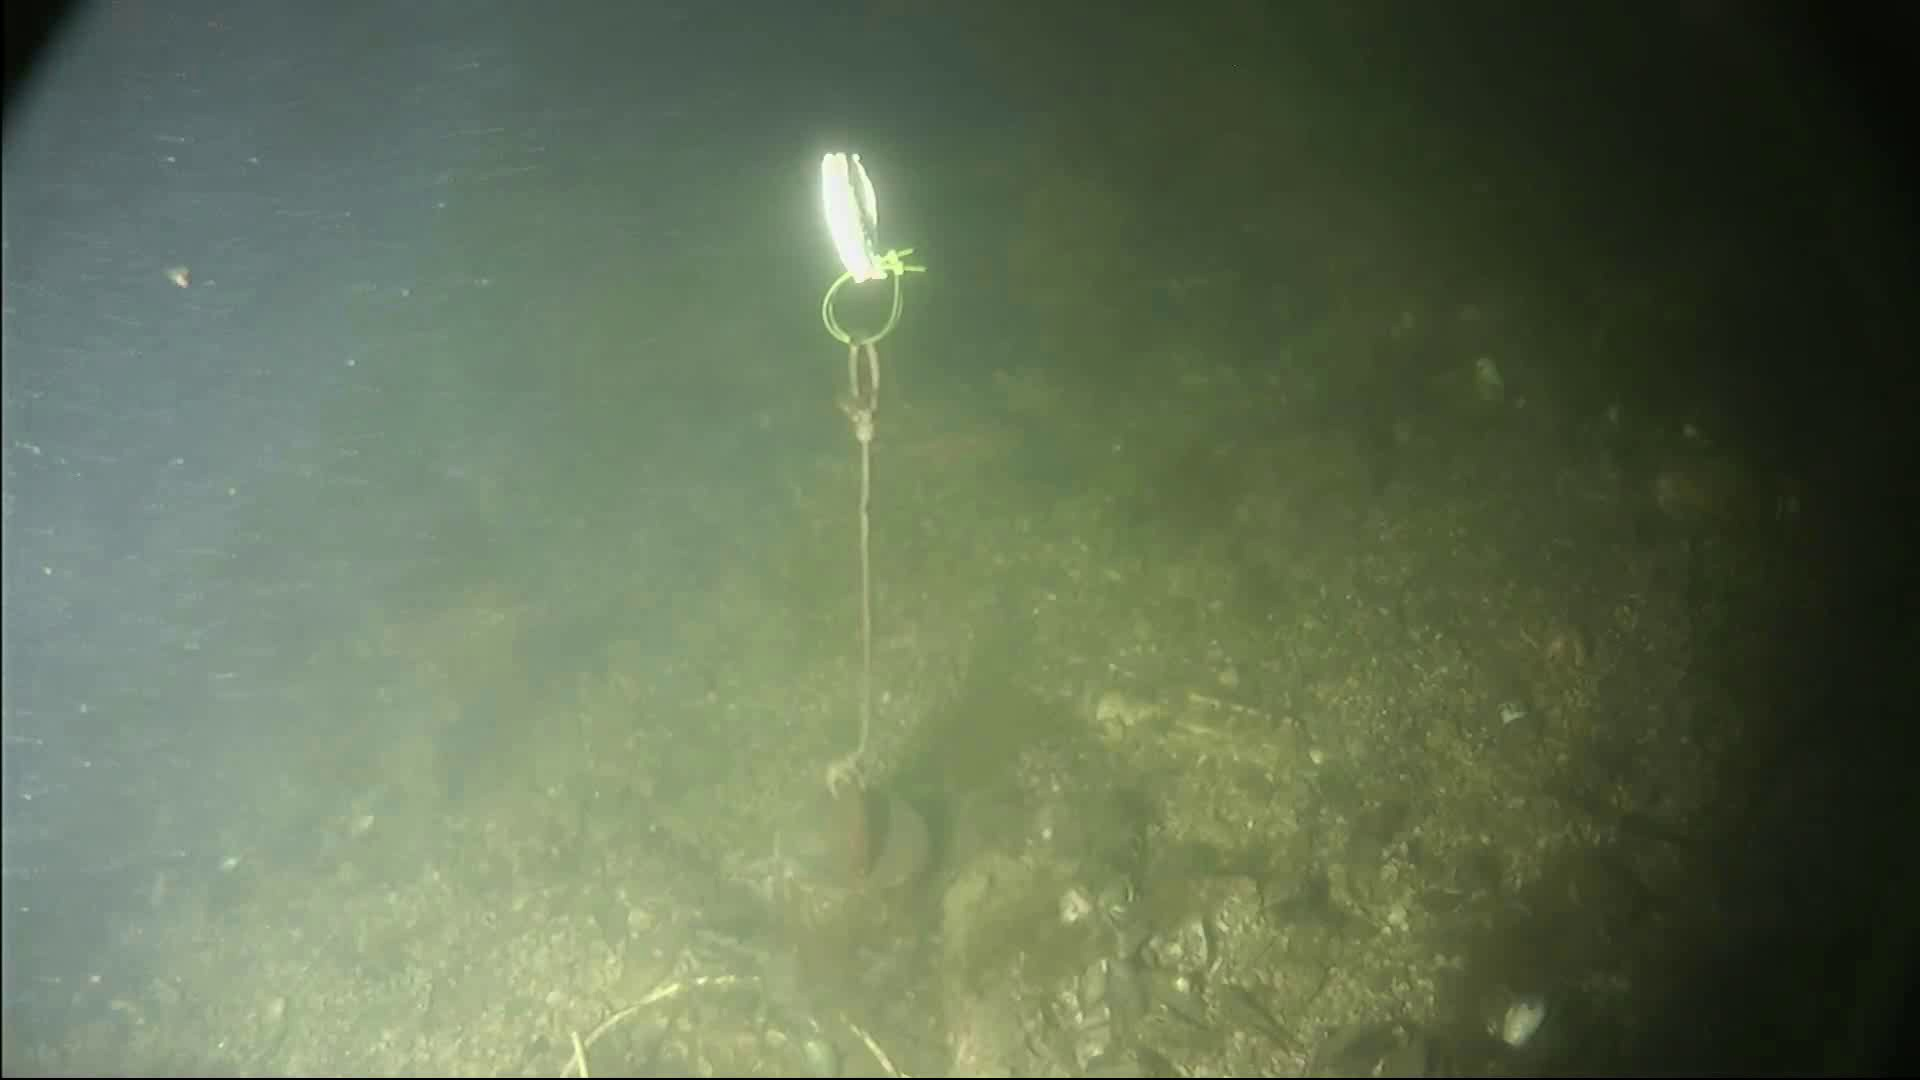

In [17]:
from IPython.display import Image, display

test_frame_path = PROJECT_DIR / "test_extracted_frame.jpg"

if success:
    cv2.imwrite(str(test_frame_path), frame)
    display(Image(filename=str(test_frame_path)))
else:
    print("Frame extraction failed.")

In [18]:
def get_split_name(label_stem):
    if label_stem in train_names:
        return "train"
    elif label_stem in valid_names:
        return "val"
    elif label_stem in test_names:
        return "test"
    else:
        return None

In [19]:
failed = []
missing_video = []
missing_split = []
processed = 0

for label_path in tqdm(label_files, desc="Extracting frames"):
    label_stem = label_path.stem
    
    split = get_split_name(label_stem)
    
    if split is None:
        missing_split.append(label_path.name)
        continue
    
    video_stem, frame_number = parse_label_filename(label_path)
    video_path = video_lookup.get(video_stem)
    
    if video_path is None:
        missing_video.append(label_path.name)
        continue
    
    image_output_path = DATASET_DIR / "images" / split / f"{label_stem}.jpg"
    label_output_path = DATASET_DIR / "labels" / split / f"{label_stem}.txt"
    
    # Skip if already extracted
    if image_output_path.exists() and label_output_path.exists():
        processed += 1
        continue
    
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number - 1)
    success, frame = cap.read()
    cap.release()
    
    if not success:
        failed.append(label_path.name)
        continue
    
    cv2.imwrite(str(image_output_path), frame)
    shutil.copy2(label_path, label_output_path)
    
    processed += 1

print("Processed:", processed)
print("Missing split:", len(missing_split))
print("Missing video:", len(missing_video))
print("Failed extraction:", len(failed))

if failed[:10]:
    print("First failed:", failed[:10])
if missing_video[:10]:
    print("First missing videos:", missing_video[:10])
if missing_split[:10]:
    print("First missing split:", missing_split[:10])

Extracting frames: 100%|██████████| 15084/15084 [14:20<00:00, 17.52it/s] 

Processed: 14674
Missing split: 410
Missing video: 0
Failed extraction: 0
First missing split: ['2019-03-19_17-07-53to2019-03-19_17-08-34_1-0201.txt', '2019-03-19_17-07-53to2019-03-19_17-08-34_1-0202.txt', '2019-03-19_17-07-53to2019-03-19_17-08-34_1-0203.txt', '2019-03-19_17-07-53to2019-03-19_17-08-34_1-0204.txt', '2019-03-19_17-07-53to2019-03-19_17-08-34_1-0205.txt', '2019-03-19_17-07-53to2019-03-19_17-08-34_1-0206.txt', '2019-03-19_17-07-53to2019-03-19_17-08-34_1-0207.txt', '2019-03-19_17-07-53to2019-03-19_17-08-34_1-0208.txt', '2019-03-19_17-07-53to2019-03-19_17-08-34_1-0209.txt', '2019-03-19_17-07-53to2019-03-19_17-08-34_1-0210.txt']
